In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Heart = pd.read_csv('heart_disease_uci.csv')
Heart.head(10)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


In [8]:
Heart.isnull().sum()
Heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [20]:
# Heart = Heart.drop(columns= ['id', 'dataset', 'ca', 'thal','slope'])
Heart['trestbps'] = Heart['trestbps'].fillna(Heart['trestbps'].median())
Heart['chol'] = Heart['chol'].fillna(Heart['chol'].median())
Heart['thalch'] = Heart['thalch'].fillna(Heart['thalch'].median())
Heart['oldpeak'] = Heart['oldpeak'].fillna(Heart['oldpeak'].median())
Heart['fbs'] = Heart['fbs'].fillna(Heart['fbs'].mode()[0])
Heart['restecg'] = Heart['restecg'].fillna(Heart['restecg'].mode()[0])
Heart['exang'] = Heart['exang'].fillna(Heart['exang'].mode()[0])
Heart['num'] = (Heart['num'] > 0).astype(int)
Heart.isnull().sum()
Heart


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0
...,...,...,...,...,...,...,...,...,...,...,...
915,54,Female,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,1
916,62,Male,typical angina,130.0,139.0,False,st-t abnormality,140.0,False,0.5,0
917,55,Male,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,1
918,58,Male,asymptomatic,130.0,385.0,True,lv hypertrophy,140.0,False,0.5,0


In [23]:
print(Heart['num'].value_counts())
Heart.dtypes
print(Heart['sex'].unique())
print(Heart['cp'].unique())
print(Heart['restecg'].unique())

num
1    509
0    411
Name: count, dtype: int64
['Male' 'Female']
['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']
['lv hypertrophy' 'normal' 'st-t abnormality']


In [ ]:
from sklearn.preprocessing import LabelEncoder
Le = LabelEncoder()
bin_cols = ['sex','exang','fbs']
for col in bin_cols:
    Heart[col] = Le.fit_transform(Heart[col])



In [ ]:
Heart = pd.get_dummies(Heart, columns = ['cp','restecg']).astype(int)



In [32]:
Heart = Heart.astype({col: int for col in Heart.select_dtypes(include='bool').columns})
Heart

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,num,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality
0,63,1,145.0,233.0,1,150.0,0,2.3,0,0,0,0,1,1,0,0
1,67,1,160.0,286.0,0,108.0,1,1.5,1,1,0,0,0,1,0,0
2,67,1,120.0,229.0,0,129.0,1,2.6,1,1,0,0,0,1,0,0
3,37,1,130.0,250.0,0,187.0,0,3.5,0,0,0,1,0,0,1,0
4,41,0,130.0,204.0,0,172.0,0,1.4,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,0,127.0,333.0,1,154.0,0,0.0,1,1,0,0,0,0,0,1
916,62,1,130.0,139.0,0,140.0,0,0.5,0,0,0,0,1,0,0,1
917,55,1,122.0,223.0,1,100.0,0,0.0,1,1,0,0,0,0,0,1
918,58,1,130.0,385.0,1,140.0,0,0.5,0,1,0,0,0,1,0,0


In [ ]:
Heart = Heart.drop(columns=['cp_typical angina', 'restecg_lv hypertrophy'])


In [37]:
Heart.shape

(920, 14)

In [42]:
X = Heart.drop(columns= 'num')
y = Heart['num']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(736, 13)
(184, 13)
(736,)
(184,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Logistic Regression:", accuracy_score(y_test, lr_pred))


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest:", accuracy_score(y_test, rf_pred))


svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
print("SVM:", accuracy_score(y_test, svm_pred))


knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
print("KNN:", accuracy_score(y_test, knn_pred))


xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print("XGBoost:", accuracy_score(y_test, xgb_pred))

Logistic Regression: 0.8097826086956522
Random Forest: 0.8206521739130435
SVM: 0.7119565217391305
KNN: 0.6902173913043478
XGBoost: 0.8152173913043478


In [44]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}


grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Best CV Accuracy: 0.8043758043758042


In [ ]:

best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    random_state=42
)

best_rf.fit(X_train, y_train)
best_pred = best_rf.predict(X_test)

print("Before tuning:", accuracy_score(y_test, rf_pred))
print("After tuning:", accuracy_score(y_test, best_pred))

print("\nClassification Report:")
from sklearn.metrics import classification_report
print(classification_report(y_test, best_pred))

Before tuning: 0.8206521739130435
After tuning: 0.8260869565217391

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.81      0.79        75
           1       0.87      0.83      0.85       109

    accuracy                           0.83       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



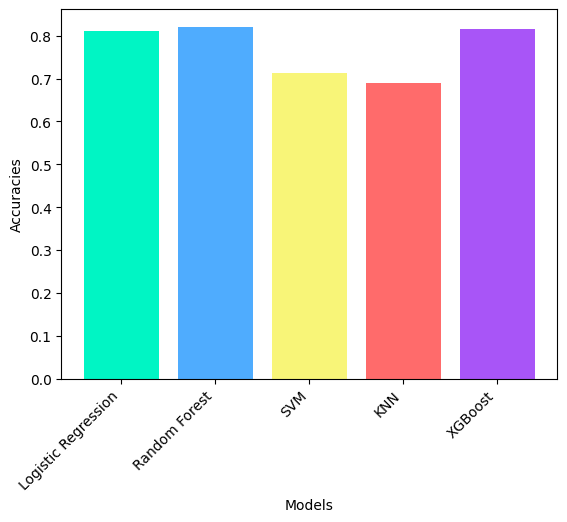

In [50]:
models_names = ['Logistic Regression', 'Random Forest', 'SVM', 'KNN', 'XGBoost']
accuracies = [0.8097, 0.8206, 0.7119, 0.6902, 0.8152]

colors = ['#00f5c4', '#4facfe', '#f8f578', '#ff6b6b', '#a855f7']
plt.bar(models_names, accuracies, color=colors)
plt.xlabel("Models")
plt.ylabel("Accuracies")
plt.xticks(rotation=45, ha = 'right')
plt.show()

In [51]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_rf, X, y, cv=5, scoring='accuracy')

print("CV Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

CV Scores: [0.74456522 0.7173913  0.88043478 0.8423913  0.64673913]
Mean Accuracy: 0.766304347826087
Standard Deviation: 0.08482440441359422
